## **_Descarga de datos_**

In [ ]:
!pip install s3fs xarray rioxarray rasterio boto3

In [4]:
import s3fs, xarray as xr, rioxarray as rxr
import pandas as pd
import re

BUCKET   = 'data-geo-raw'
AÑOS     = range(2020, 2024)   # 2020 → 2024
REGION     = 'us-east-1'

fs = s3fs.S3FileSystem(
    key='22AVZB9J3F05VX8Z843L',
    secret='CjnQAVJnc6indfEtZIuEVQkEu6NU34orXddEWDHA',
    client_kwargs={'endpoint_url': f"https://s3.{REGION}.wasabisys.com"}
)


# ─── 1. LISTAR ARCHIVOS ───────────────────────────────────────────────────────
archivos = []
for año in AÑOS:
    archivos += fs.glob(f"{BUCKET}/MODIS/{año}/MODIS_AOD_Cali_*.tif")

print(f"✅ Total de archivos: {len(archivos)}")
# Esperado: ~365 × 5 años = ~1825 archivos

# ─── 2. PARSEAR FECHA DIRECTO DEL NOMBRE ─────────────────────────────────────
# Nombre: MODIS_AOD_Cali_2020-04-07.tif → trivial con split
def fecha_desde_nombre(path):
    nombre = path.split('/')[-1]          # MODIS_AOD_Cali_2020-04-07.tif
    fecha_str = nombre.replace('MODIS_AOD_Cali_', '').replace('.tif', '')  # 2020-04-07
    return pd.to_datetime(fecha_str, format='%Y-%m-%d')

# ─── 3. CONSTRUIR EL CUBO ─────────────────────────────────────────────────────
capas = []

for ruta in sorted(archivos):  # sorted garantiza orden cronológico
    fecha = fecha_desde_nombre(ruta)
    with fs.open(ruta, 'rb') as f:
        da = rxr.open_rasterio(f, masked=True).squeeze('band', drop=True)
        da = da.assign_coords(time=fecha)
        capas.append(da)

da_aod = xr.concat(capas, dim='time').sortby('time')

print(f"✅ Cubo ensamblado: {da_aod}")
print(f"   Rango temporal: {str(da_aod.time.values[0])[:10]} → {str(da_aod.time.values[-1])[:10]}")
print(f"   Shape: {da_aod.shape}")  # (time, y, x)

✅ Total de archivos: 1461
✅ Cubo ensamblado: <xarray.DataArray (time: 1461, y: 62, x: 51)> Size: 37MB
array([[[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.396, 0.406],
        ...,
        [0.   , 0.   , 0.   , ..., 0.223, 0.32 , 0.197],
        [0.   , 0.   , 0.   , ..., 0.212, 0.231, 0.   ],
        [0.   , 0.   , 0.   , ..., 0.223, 0.233, 0.255]],

       [[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.   , 0.   , 0.   , ..., 0.294, 0.285, 0.279],
        [0.   , 0.   , 0.   , ..., 0.   , 0.273, 0.276],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.278]],

       [[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        ...,


## **_EDA_**

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 1 — INVENTARIO DE ARCHIVOS (una vez conozcas el path real)
# Ajusta PREFIX según el output del bloque anterior
# ══════════════════════════════════════════════════════════════════════════════
PREFIX = f"{BUCKET}/MODIS"   # <── cambia esto si hay subcarpetas: ej. f"{BUCKET}/MODIS/AOD"

archivos = sorted(fs.glob(f"{PREFIX}/**/*.tif"))
print(f"✅ Total de archivos .tif encontrados: {len(archivos)}")

# Parsear metadatos desde el nombre
import pandas as pd
import re

registros = []
for ruta in archivos:
    nombre = ruta.split('/')[-1]
    carpeta = ruta.split('/')[-2]          # año como carpeta
    fecha_str = nombre.replace('MODIS_AOD_Cali_', '').replace('.tif', '')
    try:
        fecha = pd.to_datetime(fecha_str, format='%Y-%m-%d')
    except:
        fecha = None
    size_bytes = fs.info(ruta)['size']
    registros.append({
        'ruta':      ruta,
        'nombre':    nombre,
        'carpeta':   carpeta,
        'fecha':     fecha,
        'size_bytes': size_bytes
    })

df_inv = pd.DataFrame(registros)
df_inv = df_inv.dropna(subset=['fecha']).sort_values('fecha').reset_index(drop=True)
df_inv['año'] = df_inv['fecha'].dt.year
df_inv['mes'] = df_inv['fecha'].dt.month

print(f"\nRango temporal: {df_inv['fecha'].min().date()} → {df_inv['fecha'].max().date()}")
print(f"Archivos con fecha válida: {len(df_inv)}")
print(f"\nArchivos por año:")
print(df_inv.groupby('año').size().rename('n_archivos').to_frame())

✅ Total de archivos .tif encontrados: 1827

Rango temporal: 2020-01-01 → 2024-12-31
Archivos con fecha válida: 1827

Archivos por año:
      n_archivos
año             
2020         366
2021         365
2022         365
2023         365
2024         366


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2 — DÍAS FALTANTES (¿hay huecos en la serie?)
# ══════════════════════════════════════════════════════════════════════════════
fecha_inicio = df_inv['fecha'].min()
fecha_fin    = df_inv['fecha'].max()

calendario_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')
fechas_disponibles  = set(df_inv['fecha'])
dias_faltantes      = [d for d in calendario_completo if d not in fechas_disponibles]

print(f"Días esperados  : {len(calendario_completo)}")
print(f"Días con archivo: {len(fechas_disponibles)}")
print(f"Días faltantes  : {len(dias_faltantes)}")

if dias_faltantes:
    df_faltantes = pd.DataFrame({'fecha': dias_faltantes})
    df_faltantes['año'] = df_faltantes['fecha'].dt.year
    df_faltantes['mes'] = df_faltantes['fecha'].dt.month
    print(f"\nDías faltantes por año:")
    print(df_faltantes.groupby('año').size().rename('dias_faltantes').to_frame())
    print(f"\nPrimeros 20 días faltantes:")
    print(df_faltantes['fecha'].dt.date.head(20).to_string(index=False))

Días esperados  : 1827
Días con archivo: 1827
Días faltantes  : 0


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 3 — ARCHIVOS SOSPECHOSOS POR TAMAÑO
# Archivos muy pequeños = probablemente vacíos o solo metadatos
# ══════════════════════════════════════════════════════════════════════════════
UMBRAL_BYTES = 2_000   # < 2 KB = sospechoso

df_inv['sospechoso'] = df_inv['size_bytes'] < UMBRAL_BYTES

print(f"Archivos sospechosos (< {UMBRAL_BYTES/1000:.0f} KB): {df_inv['sospechoso'].sum()}")
print(f"Archivos normales                                  : {(~df_inv['sospechoso']).sum()}")

print(f"\nTamaño (bytes) — estadísticas:")
print(df_inv['size_bytes'].describe().apply(lambda x: f"{x:,.0f}"))

print(f"\nDistribución de sospechosos por año:")
print(df_inv.groupby('año')['sospechoso'].sum().astype(int).rename('n_sospechosos').to_frame())

Archivos sospechosos (< 2 KB): 1002
Archivos normales                                  : 825

Tamaño (bytes) — estadísticas:
count    1,827
mean     2,569
std      1,979
min        915
25%        915
50%      1,720
75%      3,734
max      9,689
Name: size_bytes, dtype: object

Distribución de sospechosos por año:
      n_sospechosos
año                
2020            196
2021            226
2022            207
2023            194
2024            179


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 4 — NUBOSIDAD REAL (abre cada TIF y mide NaNs)
# ⚠️  Esto abre todos los archivos — puede tardar varios minutos
#     Para un chequeo rápido, usa sample_size para muestrear
# ══════════════════════════════════════════════════════════════════════════════
import rioxarray as rxr
import numpy as np

SAMPLE_SIZE = None   # None = todos los archivos | int (ej: 100) = muestra aleatoria

df_muestra = df_inv if SAMPLE_SIZE is None else df_inv.sample(SAMPLE_SIZE, random_state=42)

resultados_nubosidad = []

for _, row in df_muestra.iterrows():
    try:
        with fs.open(row['ruta'], 'rb') as f:
            da = rxr.open_rasterio(f, masked=True).squeeze('band', drop=True)
            total_px   = da.size
            nan_px     = int(np.isnan(da.values).sum())
            pct_nuboso = nan_px / total_px * 100
            resultados_nubosidad.append({
                'fecha':      row['fecha'],
                'año':        row['año'],
                'mes':        row['mes'],
                'total_px':   total_px,
                'nan_px':     nan_px,
                'pct_nuboso': pct_nuboso,
                'sospechoso': row['sospechoso']
            })
    except Exception as e:
        resultados_nubosidad.append({
            'fecha': row['fecha'], 'año': row['año'], 'mes': row['mes'],
            'total_px': 0, 'nan_px': 0, 'pct_nuboso': 100.0,
            'sospechoso': True
        })

df_nub = pd.DataFrame(resultados_nubosidad).sort_values('fecha').reset_index(drop=True)

print("RESUMEN DE NUBOSIDAD:")
print(f"  Días con 100% nuboso (datos=0): {(df_nub['pct_nuboso'] == 100).sum()}")
print(f"  Días con >80% nuboso           : {(df_nub['pct_nuboso'] > 80).sum()}")
print(f"  Días con <20% nuboso (buena calidad): {(df_nub['pct_nuboso'] < 20).sum()}")
print(f"\n  Promedio nubosidad por año:")
print(df_nub.groupby('año')['pct_nuboso'].mean().apply(lambda x: f"{x:.1f}%"))

RESUMEN DE NUBOSIDAD:
  Días con 100% nuboso (datos=0): 0
  Días con >80% nuboso           : 0
  Días con <20% nuboso (buena calidad): 1827

  Promedio nubosidad por año:
año
2020    0.0%
2021    0.0%
2022    0.0%
2023    0.0%
2024    0.0%
Name: pct_nuboso, dtype: object


/tmp/ipykernel_787/4123033290.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_787/4123033290.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("calidad_modis_raw.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


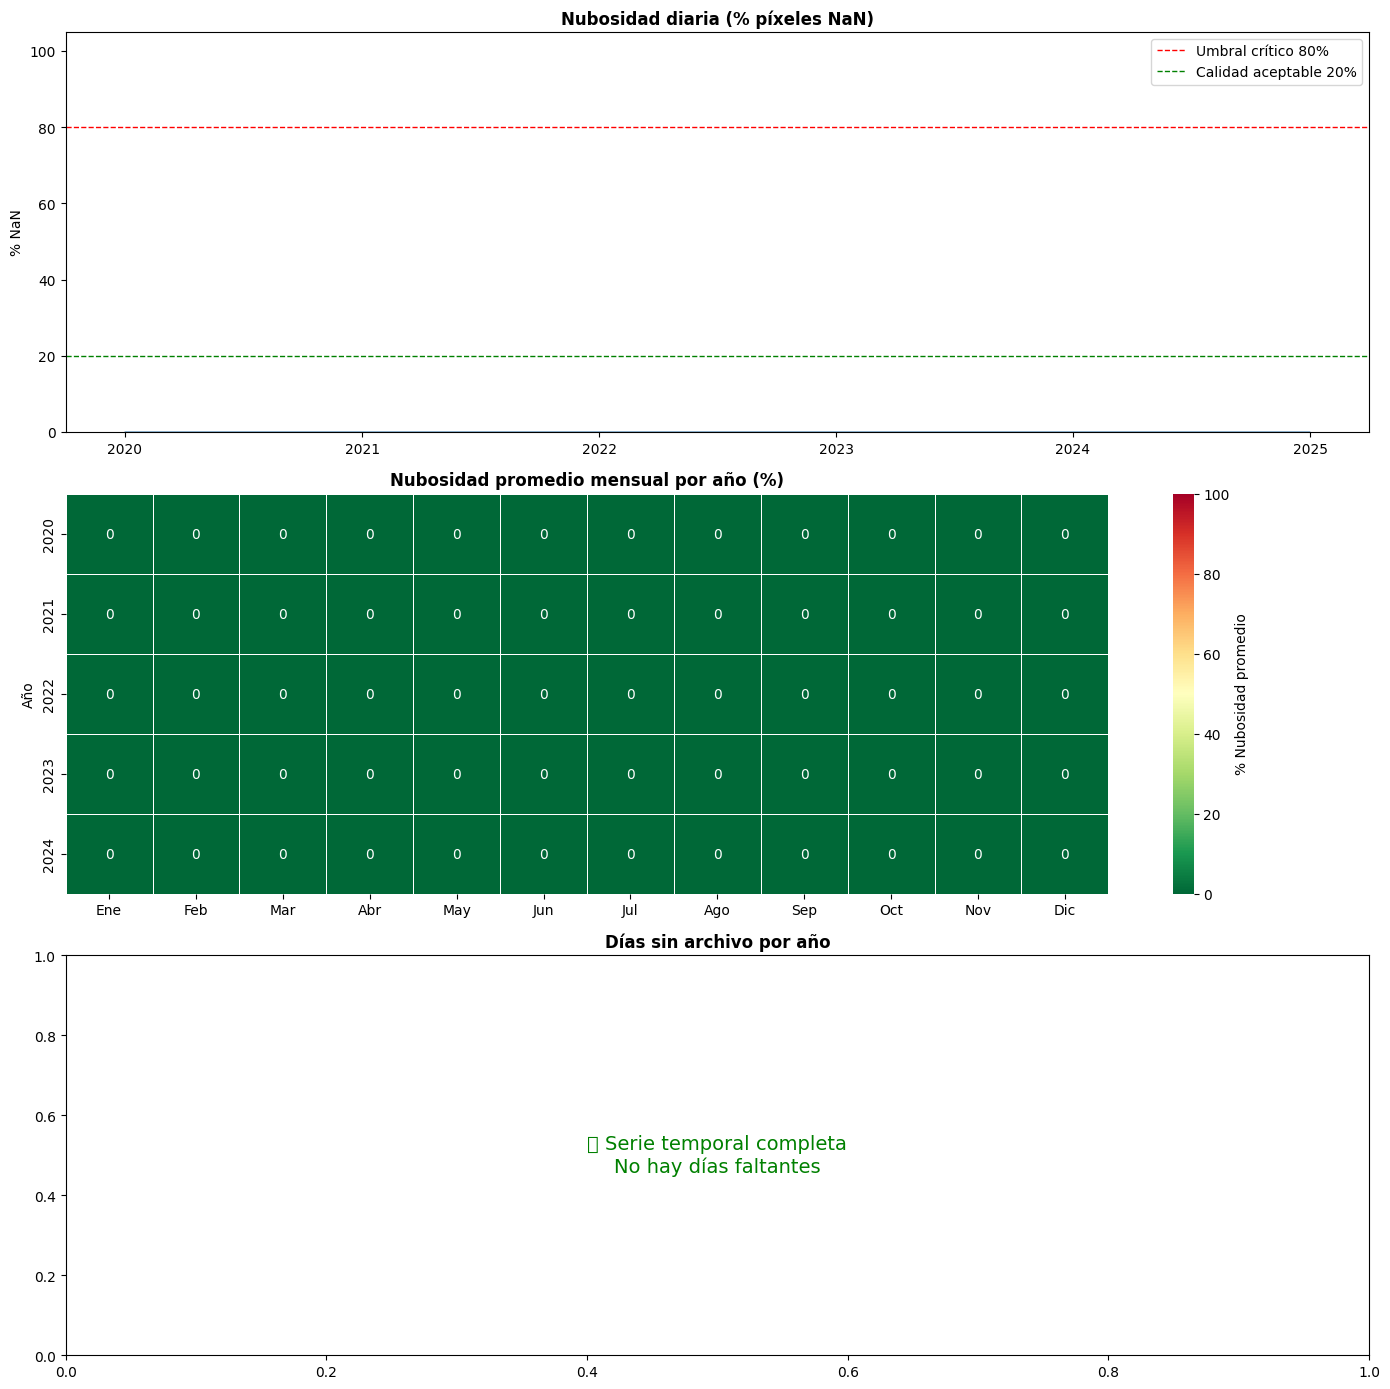

✅ Figura guardada como calidad_modis_raw.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 5 — VISUALIZACIONES DE CALIDAD
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# ── GRÁFICO 1: Serie temporal de nubosidad ────────────────────────────────────
ax = axes[0]
ax.fill_between(df_nub['fecha'], df_nub['pct_nuboso'], alpha=0.4, color='steelblue')
ax.plot(df_nub['fecha'], df_nub['pct_nuboso'], linewidth=0.6, color='steelblue')
ax.axhline(80, color='red',    linestyle='--', linewidth=1, label='Umbral crítico 80%')
ax.axhline(20, color='green',  linestyle='--', linewidth=1, label='Calidad aceptable 20%')
ax.set_title("Nubosidad diaria (% píxeles NaN)", fontweight='bold')
ax.set_ylabel("% NaN")
ax.set_ylim(0, 105)
ax.legend()

# ── GRÁFICO 2: Heatmap mensual de nubosidad promedio ────────────────────────
ax = axes[1]
matriz_nub = df_nub.pivot_table(index='año', columns='mes', values='pct_nuboso', aggfunc='mean')
matriz_nub.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
sns.heatmap(matriz_nub, annot=True, fmt=".0f", cmap="RdYlGn_r",
            vmin=0, vmax=100, linewidths=.5, ax=ax,
            cbar_kws={'label': '% Nubosidad promedio'})
ax.set_title("Nubosidad promedio mensual por año (%)", fontweight='bold')
ax.set_ylabel("Año")

# ── GRÁFICO 3: Días faltantes en el calendario ───────────────────────────────
ax = axes[2]
if dias_faltantes:
    df_f = pd.DataFrame({'fecha': dias_faltantes})
    df_f['año'] = df_f['fecha'].dt.year
    conteo = df_f.groupby('año').size()
    conteo.plot(kind='bar', ax=ax, color='salmon', edgecolor='darkred')
    ax.set_title("Días sin archivo por año", fontweight='bold')
    ax.set_ylabel("N° días faltantes")
    ax.set_xlabel("Año")
    ax.tick_params(axis='x', rotation=0)
else:
    ax.text(0.5, 0.5, '✅ Serie temporal completa\nNo hay días faltantes',
            ha='center', va='center', fontsize=14, color='green',
            transform=ax.transAxes)
    ax.set_title("Días sin archivo por año", fontweight='bold')

plt.tight_layout()
plt.savefig("calidad_modis_raw.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como calidad_modis_raw.png")

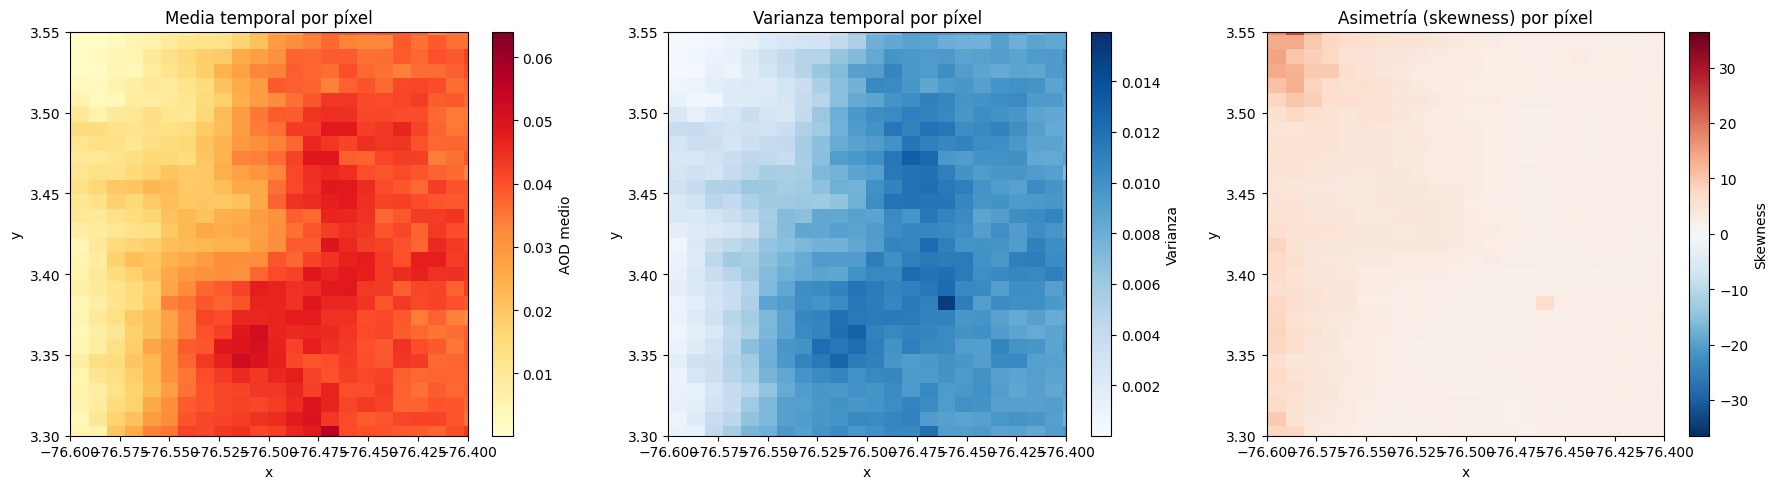

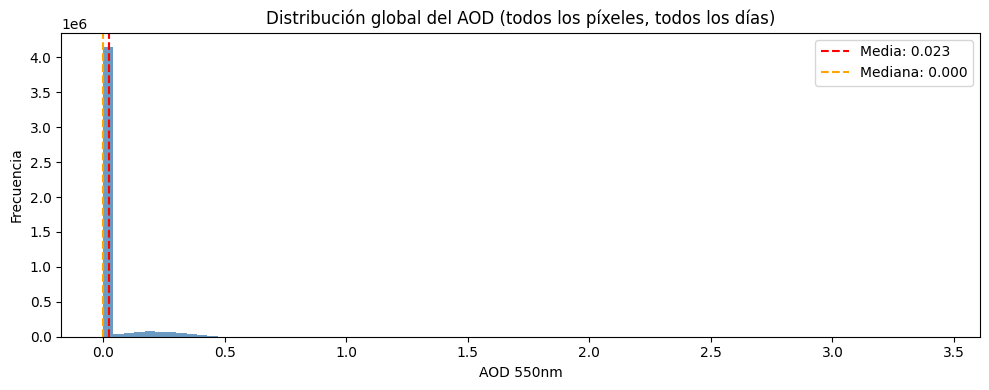

Media global  : 0.0234
Mediana global: 0.0000
Std global    : 0.0757
Skewness      : 3.4957
Kurtosis      : 14.0097


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Media, varianza y skewness por píxel
mean_map  = da_aod.mean(dim='time', skipna=True).compute()
var_map   = da_aod.var(dim='time', skipna=True).compute()
skew_map  = xr.apply_ufunc(
    stats.skew, da_aod.fillna(np.nan),
    input_core_dims=[['time']],
    kwargs={'nan_policy': 'omit'},
    vectorize=True
).compute()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mean_map.plot(ax=axes[0], cmap='YlOrRd', cbar_kwargs={'label': 'AOD medio'})
axes[0].set_title('Media temporal por píxel')

var_map.plot(ax=axes[1], cmap='Blues', cbar_kwargs={'label': 'Varianza'})
axes[1].set_title('Varianza temporal por píxel')

skew_map.plot(ax=axes[2], cmap='RdBu_r', center=0, cbar_kwargs={'label': 'Skewness'})
axes[2].set_title('Asimetría (skewness) por píxel')

for ax in axes:
    ax.set_xlim(-76.60, -76.40)
    ax.set_ylim(3.30, 3.55)

plt.tight_layout()
plt.savefig('01_estadistica_espacial.png', dpi=150)
plt.show()

# Distribución global del AOD
fig, ax = plt.subplots(figsize=(10, 4))
valores = da_aod.values.flatten()
valores = valores[~np.isnan(valores)]
ax.hist(valores, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(np.mean(valores), color='red',    linestyle='--', label=f'Media: {np.mean(valores):.3f}')
ax.axvline(np.median(valores), color='orange', linestyle='--', label=f'Mediana: {np.median(valores):.3f}')
ax.set_xlabel('AOD 550nm')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución global del AOD (todos los píxeles, todos los días)')
ax.legend()
plt.tight_layout()
plt.savefig('01b_distribucion_global.png', dpi=150)
plt.show()

print(f"Media global  : {np.mean(valores):.4f}")
print(f"Mediana global: {np.median(valores):.4f}")
print(f"Std global    : {np.std(valores):.4f}")
print(f"Skewness      : {stats.skew(valores):.4f}")
print(f"Kurtosis      : {stats.kurtosis(valores):.4f}")

In [13]:
!pip install pymannkendall

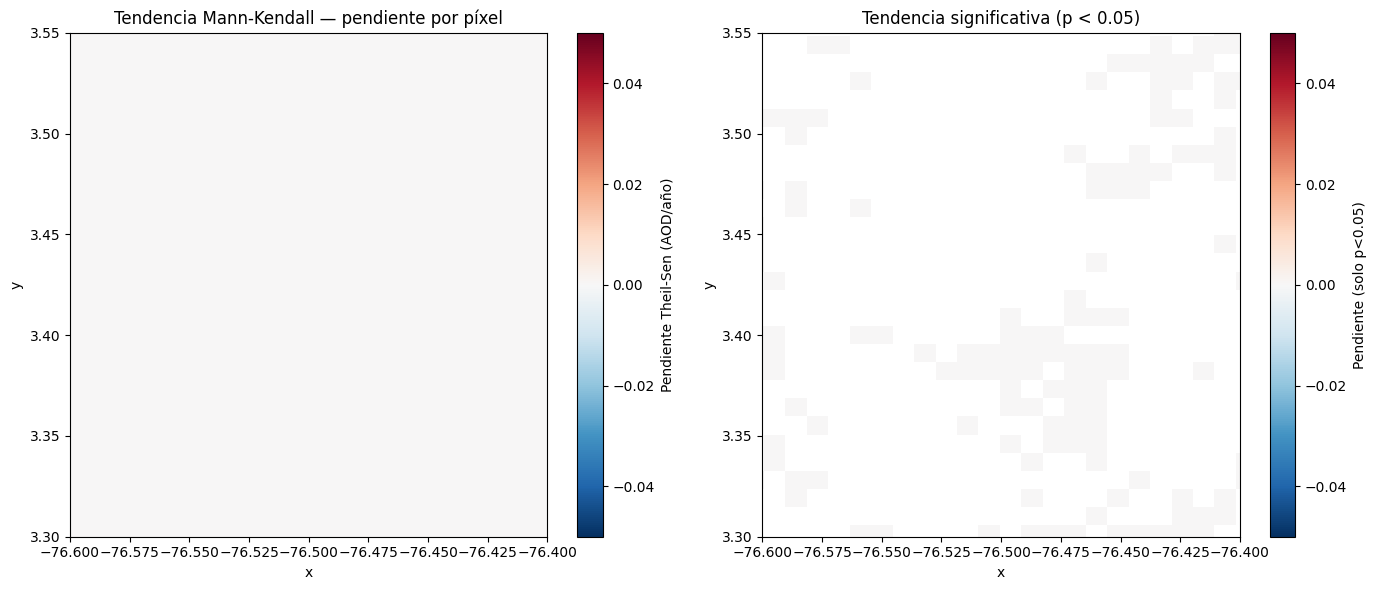

Píxeles con tendencia positiva  : 0.0%
Píxeles con tendencia p<0.05   : 21.0%


In [14]:
import pymannkendall as mk   # pip install pymannkendall

# Mann-Kendall vectorizado — puede tardar ~2-5 min según tamaño del grid
def mk_pixel(serie):
    serie = serie[~np.isnan(serie)]
    if len(serie) < 10:
        return np.nan, np.nan
    res = mk.original_test(serie)
    return res.slope, float(res.p < 0.05)   # Theil-Sen slope + significancia

shape_yx = (da_aod.sizes['y'], da_aod.sizes['x'])
slopes   = np.full(shape_yx, np.nan)
signif   = np.full(shape_yx, np.nan)

data_np = da_aod.values  # shape: (time, y, x)

for i in range(shape_yx[0]):
    for j in range(shape_yx[1]):
        slopes[i, j], signif[i, j] = mk_pixel(data_np[:, i, j])

# Convertir a DataArrays con coordenadas
slopes_da = xr.DataArray(slopes, coords={'y': da_aod.y, 'x': da_aod.x}, dims=['y', 'x'])
signif_da = xr.DataArray(signif, coords={'y': da_aod.y, 'x': da_aod.x}, dims=['y', 'x'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

slopes_da.plot(ax=axes[0], cmap='RdBu_r', center=0,
               cbar_kwargs={'label': 'Pendiente Theil-Sen (AOD/año)'})
axes[0].set_title('Tendencia Mann-Kendall — pendiente por píxel')
axes[0].set_xlim(-76.60, -76.40); axes[0].set_ylim(3.30, 3.55)

# Enmascarar píxeles no significativos (p >= 0.05)
slopes_signif = slopes_da.where(signif_da == 1)
slopes_signif.plot(ax=axes[1], cmap='RdBu_r', center=0,
                   cbar_kwargs={'label': 'Pendiente (solo p<0.05)'})
axes[1].set_title('Tendencia significativa (p < 0.05)')
axes[1].set_xlim(-76.60, -76.40); axes[1].set_ylim(3.30, 3.55)

plt.tight_layout()
plt.savefig('02_mann_kendall.png', dpi=150)
plt.show()

pct_positiva = float((slopes > 0).sum() / (~np.isnan(slopes)).sum() * 100)
pct_signif   = float((signif == 1).sum() / (~np.isnan(signif)).sum() * 100)
print(f"Píxeles con tendencia positiva  : {pct_positiva:.1f}%")
print(f"Píxeles con tendencia p<0.05   : {pct_signif:.1f}%")

Zona Industrial (Yumbo): varianza residuo = 81.8% del total
Zona Cultivos (Vía Palmira): varianza residuo = 77.9% del total
Zona Residencial (Sur/Pance): varianza residuo = 63.2% del total


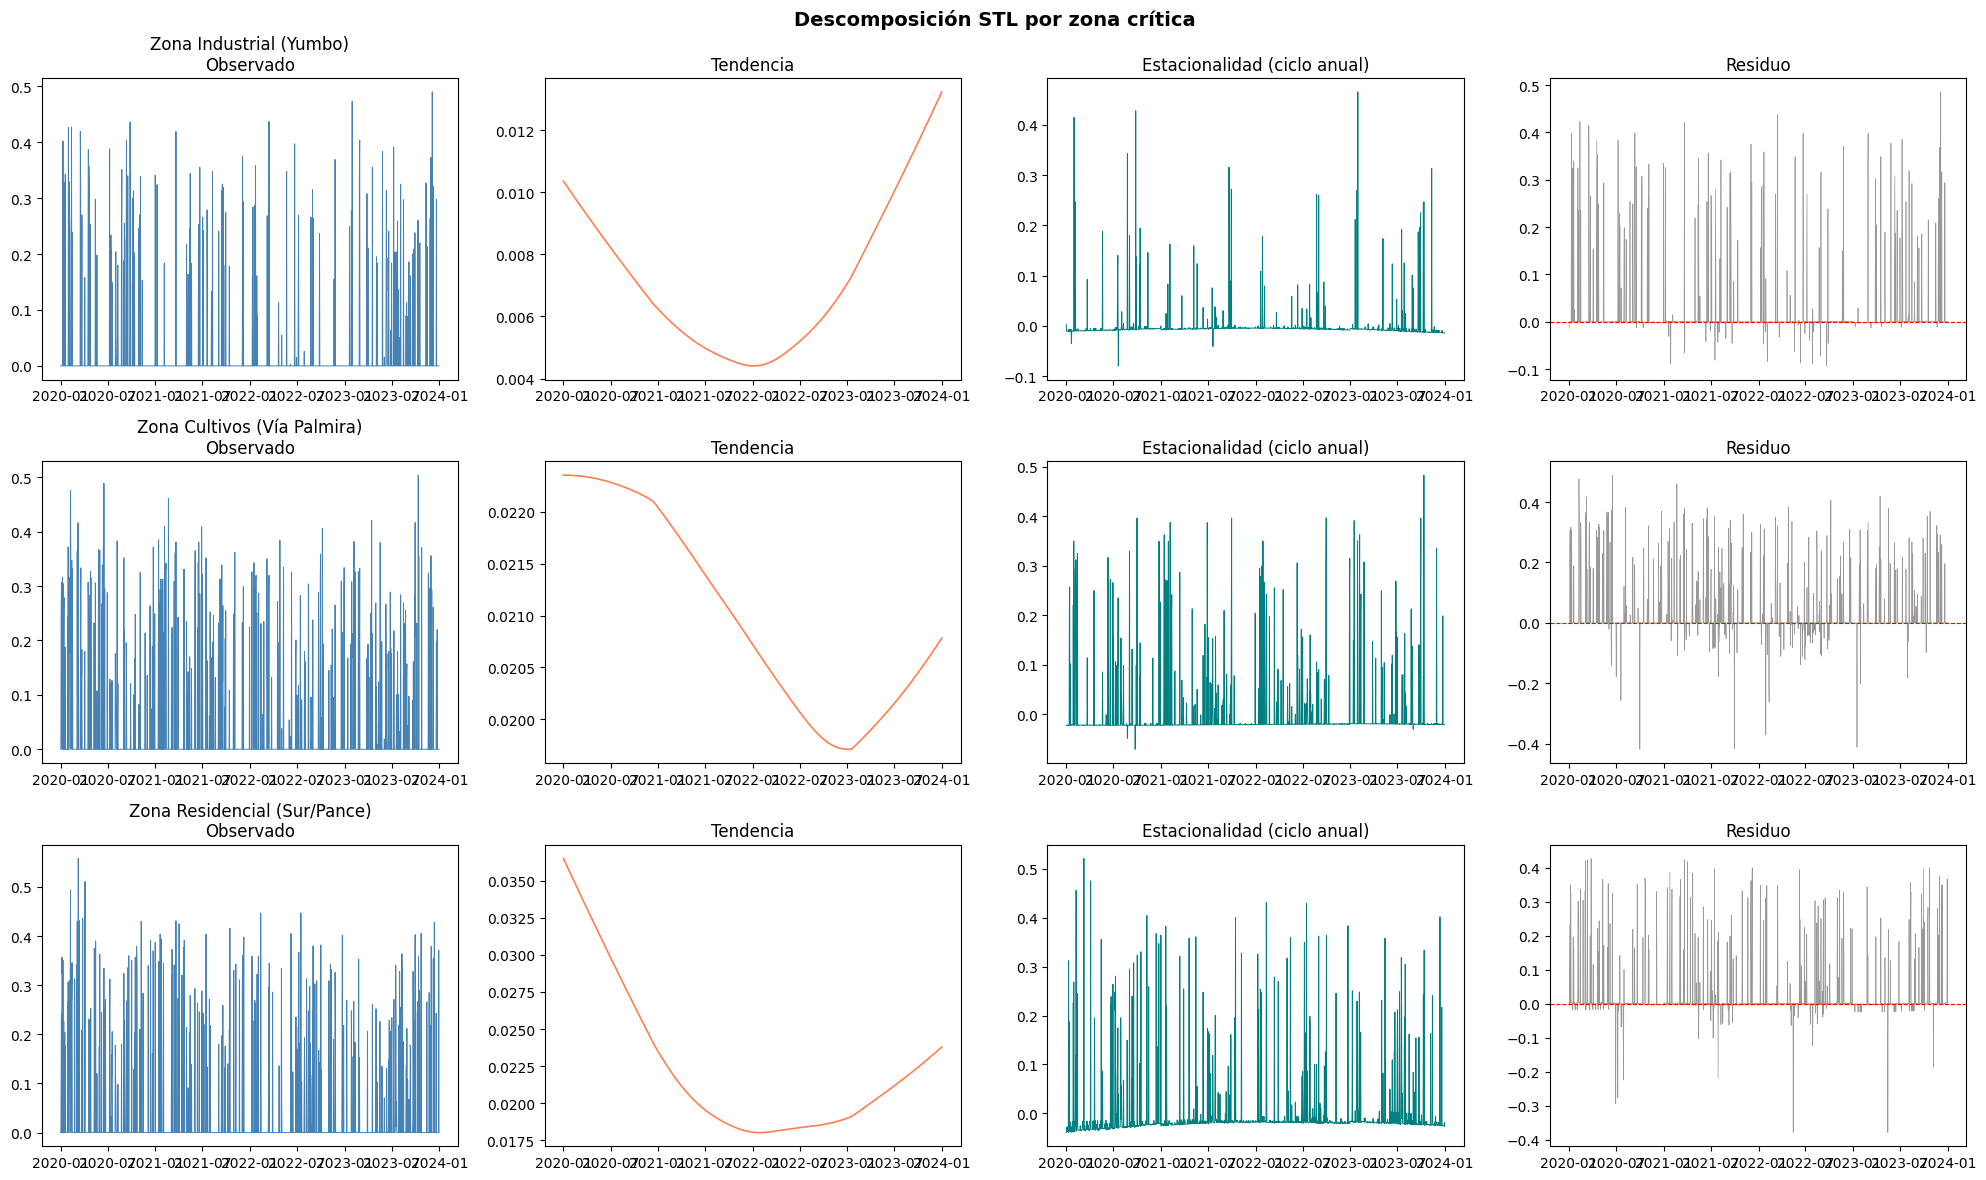

In [15]:
from statsmodels.tsa.seasonal import STL

# Aplicar en las 3 zonas críticas del EDA original
zonas = {
    'Zona Industrial (Yumbo)': {'lat': 3.515, 'lon': -76.515},
    'Zona Cultivos (Vía Palmira)': {'lat': 3.480, 'lon': -76.430},
    'Zona Residencial (Sur/Pance)': {'lat': 3.350, 'lon': -76.530}
}

fig, axes = plt.subplots(len(zonas), 4, figsize=(20, 4 * len(zonas)))

for idx, (nombre, coords) in enumerate(zonas.items()):
    serie = (da_aod
             .sel(y=coords['lat'], x=coords['lon'], method='nearest')
             .to_series()
             .dropna()
             .asfreq('D')
             .interpolate(method='linear'))

    stl = STL(serie, period=365, robust=True)
    res = stl.fit()

    axes[idx, 0].plot(serie.index, res.observed,  color='steelblue', linewidth=0.7)
    axes[idx, 0].set_title(f'{nombre}\nObservado')

    axes[idx, 1].plot(serie.index, res.trend,     color='coral',     linewidth=1.2)
    axes[idx, 1].set_title('Tendencia')

    axes[idx, 2].plot(serie.index, res.seasonal,  color='teal',      linewidth=0.7)
    axes[idx, 2].set_title('Estacionalidad (ciclo anual)')

    axes[idx, 3].plot(serie.index, res.resid,     color='gray',      linewidth=0.5, alpha=0.8)
    axes[idx, 3].axhline(0, color='red', linewidth=0.8, linestyle='--')
    axes[idx, 3].set_title('Residuo')

    var_total   = np.var(res.observed)
    var_residuo = np.var(res.resid)
    print(f"{nombre}: varianza residuo = {var_residuo/var_total*100:.1f}% del total")

plt.suptitle('Descomposición STL por zona crítica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_descomposicion_stl.png', dpi=150)
plt.show()

In [19]:
!pip install libpysal esda

Moran's I global : 0.9730
p-value          : 0.0010
→ Clustering espacial significativo


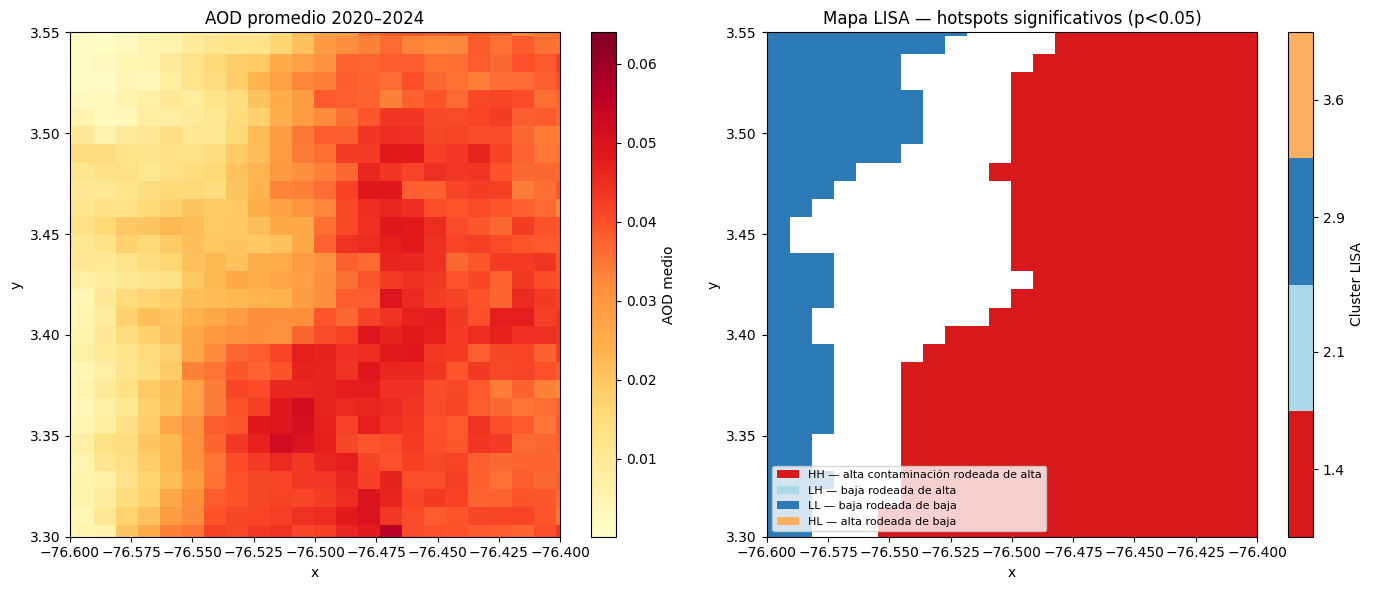

In [21]:
import libpysal                        # pip install libpysal esda
from esda.moran import Moran, Moran_Local

# Usar el promedio temporal para el análisis espacial
aod_mean = da_aod.mean(dim='time', skipna=True).compute()
z = aod_mean.values.flatten()
mask = ~np.isnan(z)
z_valid = z[mask]

# Coordenadas de los píxeles válidos
yy, xx = np.meshgrid(aod_mean.y.values, aod_mean.x.values, indexing='ij')
coords = np.column_stack([xx.flatten()[mask], yy.flatten()[mask]])

# Matriz de pesos espaciales (Queen, k=8 vecinos)
w = libpysal.weights.KNN.from_array(coords, k=8)
w.transform = 'r'   # row-standardized

# Moran global
moran = Moran(z_valid, w)
print(f"Moran's I global : {moran.I:.4f}")
print(f"p-value          : {moran.p_sim:.4f}")
print(f"→ {'Clustering espacial significativo' if moran.p_sim < 0.05 else 'Sin clustering significativo'}")

# LISA (Moran local)
lisa = Moran_Local(z_valid, w)

# Reconstruir grid para visualizar
lisa_q   = np.full(z.shape, np.nan)
lisa_sig = np.full(z.shape, np.nan)
lisa_q[mask]   = lisa.q        # cuadrante HH=1, LH=2, LL=3, HL=4
lisa_sig[mask] = (lisa.p_sim < 0.05).astype(float)

# Solo mostrar clusters significativos
lisa_masked = np.where((lisa_sig == 1), lisa_q, np.nan)

lisa_da = xr.DataArray(
    lisa_masked.reshape(aod_mean.shape),
    coords={'y': aod_mean.y, 'x': aod_mean.x},
    dims=['y', 'x']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

aod_mean.plot(ax=axes[0], cmap='YlOrRd', cbar_kwargs={'label': 'AOD medio'})
axes[0].set_title('AOD promedio 2020–2024')
axes[0].set_xlim(-76.60, -76.40); axes[0].set_ylim(3.30, 3.55)

cmap_lisa = plt.cm.colors.ListedColormap(['#d7191c','#abd9e9','#2c7bb6','#fdae61'])
lisa_da.plot(ax=axes[1], cmap=cmap_lisa, vmin=1, vmax=4,
             cbar_kwargs={'label': 'Cluster LISA', 'ticks': [1.4, 2.1, 2.9, 3.6]})
axes[1].set_title('Mapa LISA — hotspots significativos (p<0.05)')
axes[1].set_xlim(-76.60, -76.40); axes[1].set_ylim(3.30, 3.55)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d7191c', label='HH — alta contaminación rodeada de alta'),
    Patch(facecolor='#abd9e9', label='LH — baja rodeada de alta'),
    Patch(facecolor='#2c7bb6', label='LL — baja rodeada de baja'),
    Patch(facecolor='#fdae61', label='HL — alta rodeada de baja'),
]
axes[1].legend(handles=legend_elements, loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('04_lisa_moran.png', dpi=150)
plt.show()

In [22]:
!pip install scikit-gstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 710.3/710.3 kB 5.7 MB/s eta 0:00:00


spherical Variogram
-------------------
Estimator:         matheron
Effective Range:   25.00
Sill:              0.00
Nugget:            0.00
        

Rango    : 25.00 km  ← hasta aquí se propaga la autocorrelación
Meseta   : 0.0002
Pepita   : 0.0000
Nugget % : 0.0%  ← % de varianza no espacial


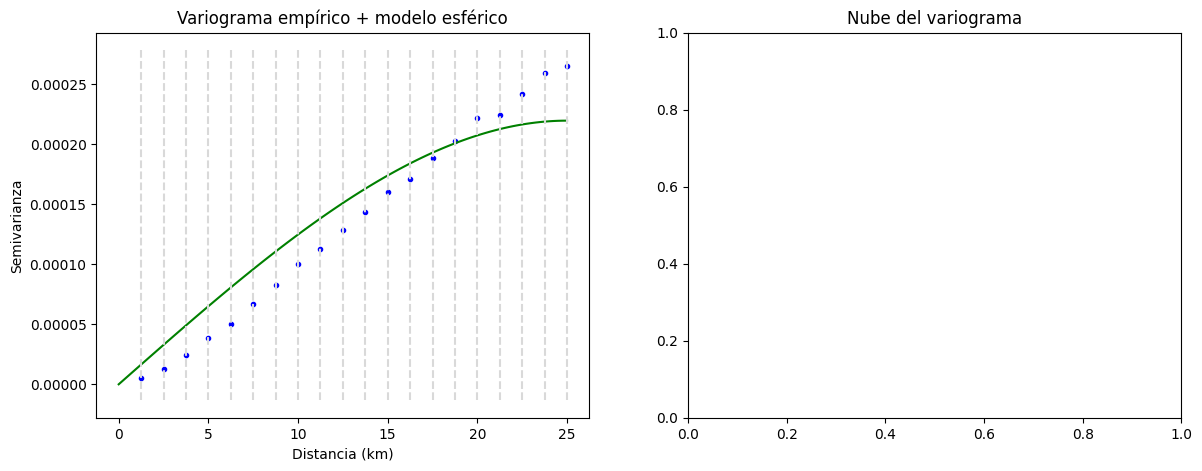

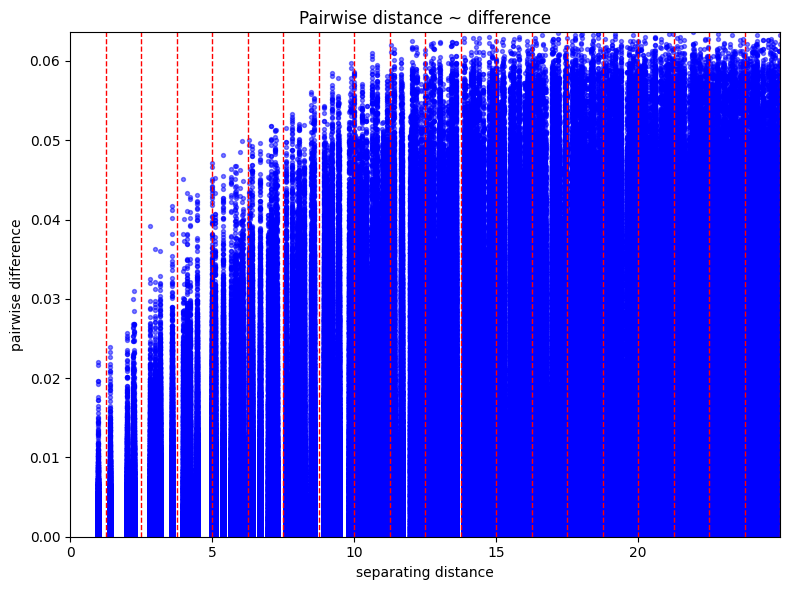

In [24]:
import skgstat as skg   # pip install scikit-gstat
import matplotlib.pyplot as plt
import numpy as np

# Muestra del promedio temporal (variograma sobre el espacio)
aod_mean = da_aod.mean(dim='time', skipna=True).compute()
z = aod_mean.values.flatten()
mask = ~np.isnan(z)
z_valid = z[mask]

yy, xx = np.meshgrid(aod_mean.y.values, aod_mean.x.values, indexing='ij')
# Convertir grados a km aproximados (zona Cali ~3.4°N)
coords_km = np.column_stack([
    xx.flatten()[mask] * 111.32 * np.cos(np.radians(3.4)),
    yy.flatten()[mask] * 111.32
])

# Si hay demasiados píxeles, muestrear
if len(z_valid) > 3000:
    idx = np.random.choice(len(z_valid), 3000, replace=False)
    z_valid   = z_valid[idx]
    coords_km = coords_km[idx]

V = skg.Variogram(coords_km, z_valid, model='spherical', n_lags=20, maxlag=25)

print(V)
print(f"\nRango    : {V.parameters[0]:.2f} km  ← hasta aquí se propaga la autocorrelación")
print(f"Meseta   : {V.parameters[1]:.4f}")
print(f"Pepita   : {V.parameters[2]:.4f}")
print(f"Nugget % : {V.parameters[2]/V.parameters[1]*100:.1f}%  ← % de varianza no espacial")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
V.plot(axes=axes[0])
axes[0].set_title('Variograma empírico + modelo esférico')
axes[0].set_xlabel('Distancia (km)')
axes[0].set_ylabel('Semivarianza')

plt.sca(axes[1]) # Make axes[1] the current active axes
V.distance_difference_plot()
axes[1].set_title('Nube del variograma')

plt.tight_layout()
plt.savefig('06_variograma.png', dpi=150)
plt.show()

---------------------------------------

Calculando promedios estacionales...


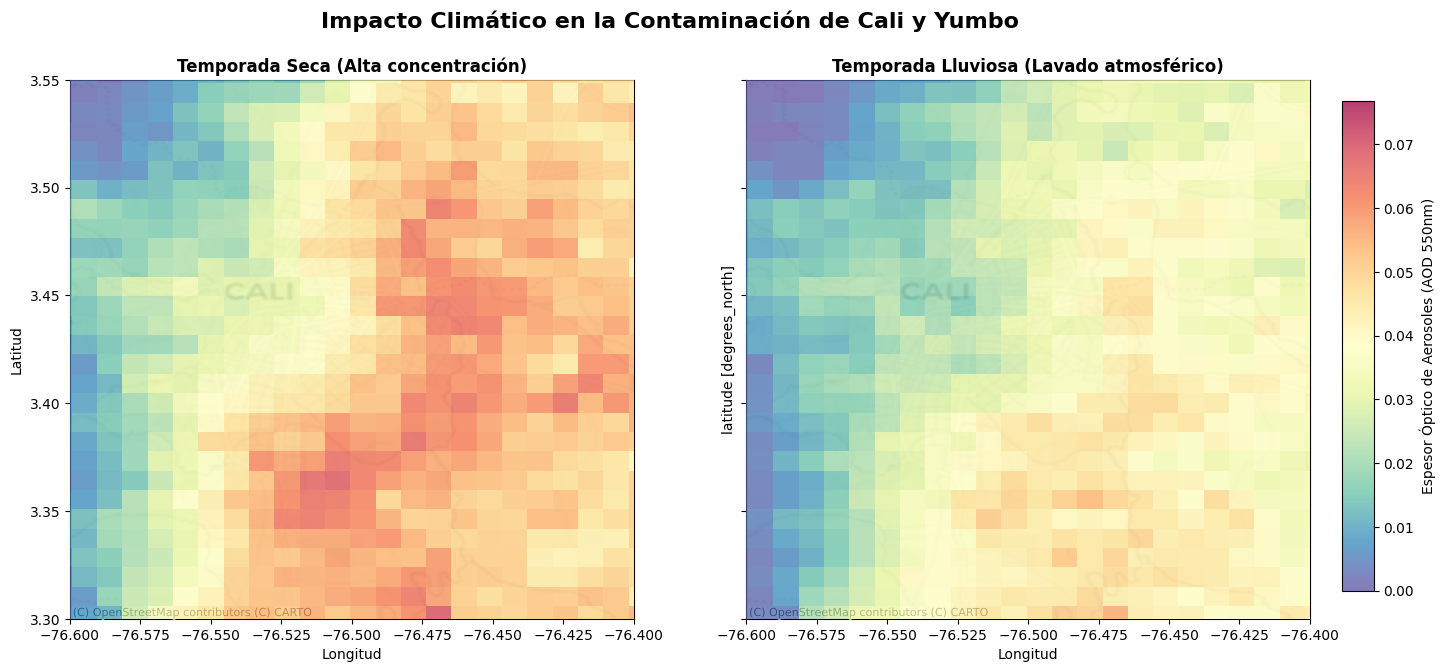

In [ ]:
import contextily as cx
import matplotlib.pyplot as plt

print("Calculando promedios estacionales...")
# Definimos meses secos (Verano/Vientos) y lluviosos (Invierno) en Cali
meses_secos = [7, 8, 9, 12, 1, 2]
meses_lluvia = [3, 4, 5, 10, 11]

aod_seco = da_aod.sel(time=da_aod['time.month'].isin(meses_secos)).mean(dim='time', skipna=True).compute()
aod_lluvia = da_aod.sel(time=da_aod['time.month'].isin(meses_lluvia)).mean(dim='time', skipna=True).compute()

# Configurar el mapa dual
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Escala de colores estandarizada para ambos mapas (para que sean comparables)
vmin, vmax = float(aod_lluvia.min()), float(aod_seco.max())

# ─── MAPA 1: TEMPORADA SECA ───
aod_seco.plot(
    ax=axes[0], cmap='Spectral_r', vmin=vmin, vmax=vmax, add_colorbar=False,
    alpha=0.75, zorder=10 # Semitransparente y por encima del mapa
)
# Añadir el mapa de Cali al fondo
cx.add_basemap(axes[0], crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zorder=0)

axes[0].set_title("Temporada Seca (Alta concentración)", fontweight="bold")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")

# Ajustar límites exactos a la huella de Cali
axes[0].set_xlim(-76.60, -76.40)
axes[0].set_ylim(3.30, 3.55)


# ─── MAPA 2: TEMPORADA LLUVIOSA ───
im = aod_lluvia.plot(
    ax=axes[1], cmap='Spectral_r', vmin=vmin, vmax=vmax, add_colorbar=False,
    alpha=0.75, zorder=10
)
# Añadir el mapa de Cali al fondo
cx.add_basemap(axes[1], crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zorder=0)

axes[1].set_title("Temporada Lluviosa (Lavado atmosférico)", fontweight="bold")
axes[1].set_xlabel("Longitud")

# Ajustar límites exactos
axes[1].set_xlim(-76.60, -76.40)
axes[1].set_ylim(3.30, 3.55)


# ─── BARRA DE COLORES COMPARTIDA ───
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Espesor Óptico de Aerosoles (AOD 550nm)')

plt.suptitle("Impacto Climático en la Contaminación de Cali y Yumbo", fontsize=16, fontweight="bold")
plt.show()

Generando matriz de cobertura (Píxeles válidos)...


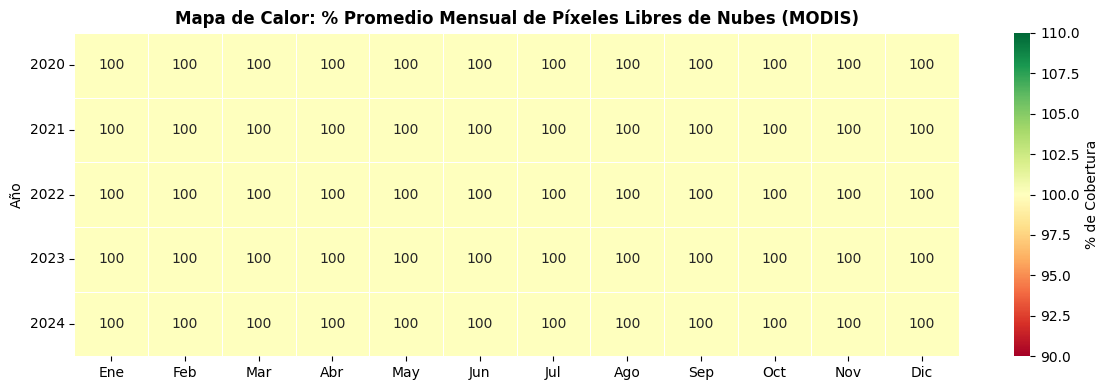

In [ ]:
print("Generando matriz de cobertura (Píxeles válidos)...")
# Calcular % válido diario
total_px = da_aod.sizes['x'] * da_aod.sizes['y']
validos_diarios = da_aod.notnull().sum(dim=['x', 'y']).to_series() / total_px * 100

# Convertir a DataFrame y extraer Año y Mes
df_calidad = pd.DataFrame({'pct_valido': validos_diarios})
df_calidad['Año'] = df_calidad.index.year
df_calidad['Mes'] = df_calidad.index.month

# Agrupar promedio por Año y Mes
matriz_calidad = df_calidad.pivot_table(index='Año', columns='Mes', values='pct_valido', aggfunc='mean')

# Reemplazar números de meses por nombres
matriz_calidad.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 4))
sns.heatmap(matriz_calidad, annot=True, fmt=".0f", cmap="RdYlGn", cbar_kws={'label': '% de Cobertura'}, linewidths=.5)

plt.title("Mapa de Calor: % Promedio Mensual de Píxeles Libres de Nubes (MODIS)", fontweight="bold")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

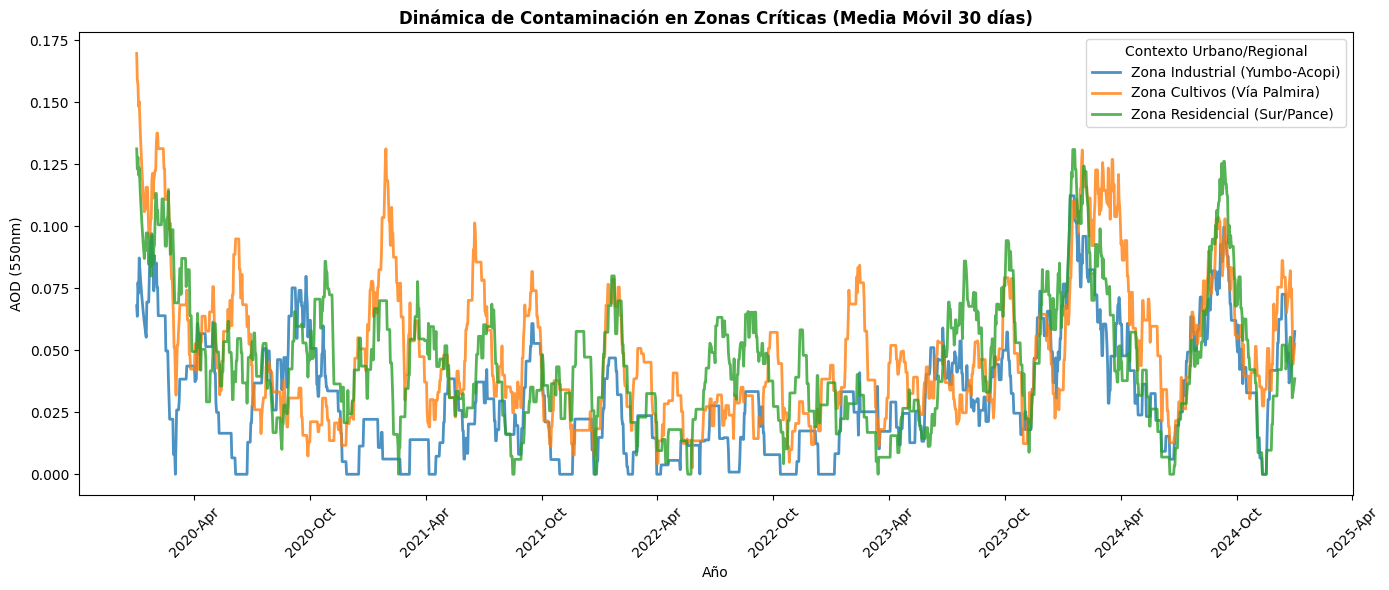

In [ ]:
import matplotlib.dates as mdates

# Puntos clave según el contexto del proyecto
zonas_criticas = {
    'Zona Industrial (Yumbo-Acopi)': {'lat': 3.515, 'lon': -76.515},
    'Zona Cultivos (Vía Palmira)':   {'lat': 3.480, 'lon': -76.430}, # Quemas de caña
    'Zona Residencial (Sur/Pance)':  {'lat': 3.350, 'lon': -76.530}
}

plt.figure(figsize=(14, 6))

for nombre, coords in zonas_criticas.items():
    # Extraemos la serie del píxel y calculamos una media móvil (Rolling Mean) de 30 días
    serie = da_aod.sel(y=coords['lat'], x=coords['lon'], method='nearest').to_series().dropna()
    serie_suavizada = serie.rolling(window=30, center=True, min_periods=5).mean()

    plt.plot(serie_suavizada.index, serie_suavizada.values, label=nombre, linewidth=2, alpha=0.8)

plt.title("Dinámica de Contaminación en Zonas Críticas (Media Móvil 30 días)", fontweight="bold")
plt.ylabel("AOD (550nm)")
plt.xlabel("Año")
plt.legend(title="Contexto Urbano/Regional")

# Formato de fechas en el eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()